In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
import json
import tensorflow as tf
from tensorflow.keras import layers, models

print("Libraries imported successfully!")
print(f"TensorFlow Version: {tf.__version__}")

Libraries imported successfully!
TensorFlow Version: 2.20.0


Sample IoT Payload: {'device_id': 'ESP32_NODE_01', 'temperature': np.float64(25.25)}
Generated SHA-256 Hash for Blockchain: 96df84d762338ce5458001ab49c3e6e823e0ee509686c3e3d441b040ba922c20


/tmp/ipykernel_2176/2488189916.py:16: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  'timestamp': pd.date_range(start='2026-08-26', periods=time_steps, freq='S'),


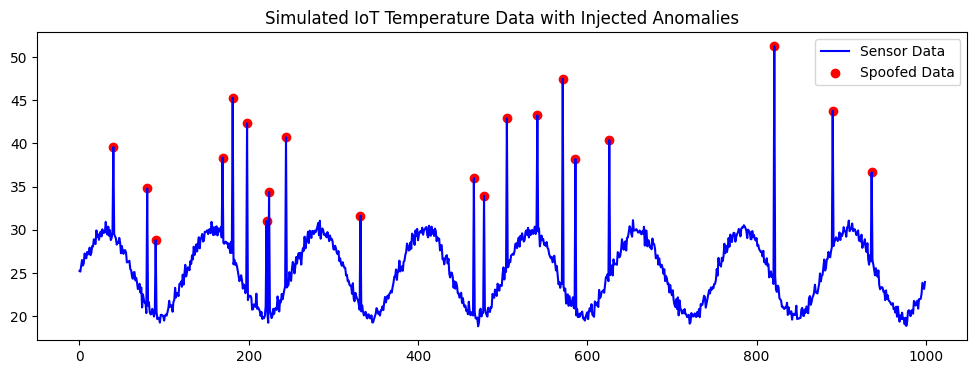

In [ ]:
# 1. Simulate IoT Sensor Data (e.g., Temperature readings from an ESP32)
np.random.seed(42)
time_steps = 1000

# Normal operational data (Sine wave + slight noise)
time = np.linspace(0, 50, time_steps)
normal_temp = 25 + 5 * np.sin(time) + np.random.normal(0, 0.5, time_steps)

# Inject Anomalies (Simulating a sensor spoofing attack or DDoS data burst)
anomalous_temp = normal_temp.copy()
attack_indices = np.random.choice(time_steps, size=20, replace=False)
anomalous_temp[attack_indices] += np.random.normal(15, 5, 20) # Sudden massive spikes

# Create a DataFrame
iot_data = pd.DataFrame({
    'timestamp': pd.date_range(start='2026-08-26', periods=time_steps, freq='S'),
    'temperature': anomalous_temp,
    'is_attack': [1 if i in attack_indices else 0 for i in range(time_steps)]
})

# 2. Cryptographic Hashing Function (Simulating the Edge/Blockchain Prep)
def generate_iot_payload_hash(sensor_value, device_id="ESP32_NODE_01"):
    payload = {
        "device_id": device_id,
        "temperature": round(sensor_value, 2)
    }
    payload_string = json.dumps(payload, sort_keys=True).encode('utf-8')
    payload_hash = hashlib.sha256(payload_string).hexdigest()
    return payload, payload_hash

# Test the hashing function on the first reading
sample_payload, sample_hash = generate_iot_payload_hash(iot_data['temperature'].iloc[0])
print(f"Sample IoT Payload: {sample_payload}")
print(f"Generated SHA-256 Hash for Blockchain: {sample_hash}")

# Plot the raw simulated data
plt.figure(figsize=(12, 4))
plt.plot(iot_data['temperature'], label='Sensor Data', color='blue')
plt.scatter(attack_indices, iot_data['temperature'].iloc[attack_indices], color='red', label='Spoofed Data')
plt.title("Simulated IoT Temperature Data with Injected Anomalies")
plt.legend()
plt.show()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

Training the Edge AI Model...
Training Complete!


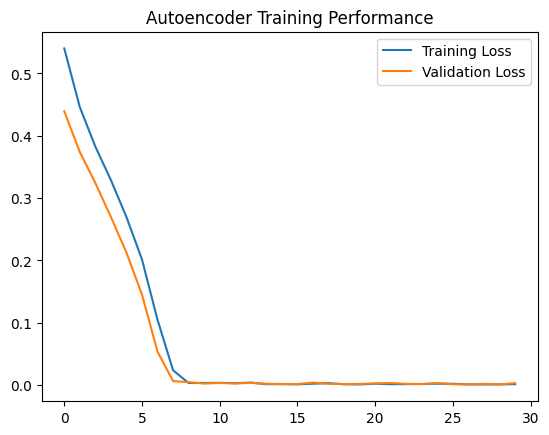

In [ ]:
# Prepare data for the Neural Network
# We train ONLY on normal data (simulating a baseline of standard operations)
X_train = normal_temp.reshape(-1, 1)

# Normalize the data for better training
min_val = tf.reduce_min(X_train)
max_val = tf.reduce_max(X_train)
X_train_scaled = (X_train - min_val) / (max_val - min_val)

X_test_scaled = (iot_data['temperature'].values.reshape(-1, 1) - min_val) / (max_val - min_val)

# Build a lightweight Autoencoder suitable for TinyML / Edge Deployment
model = models.Sequential([
    layers.Dense(8, activation='relu', input_shape=(1,)), # Encoder
    layers.Dense(4, activation='relu'),                   # Bottleneck
    layers.Dense(8, activation='relu'),                   # Decoder
    layers.Dense(1, activation='linear')                  # Output
])

model.compile(optimizer='adam', loss='mae')
model.summary()

# Train the model
print("Training the Edge AI Model...")
history = model.fit(X_train_scaled, X_train_scaled,
                    epochs=30,
                    batch_size=32,
                    validation_split=0.1,
                    verbose=0)
print("Training Complete!")

# Plot Training Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Performance')
plt.legend()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Anomaly Detection Threshold: 0.1413


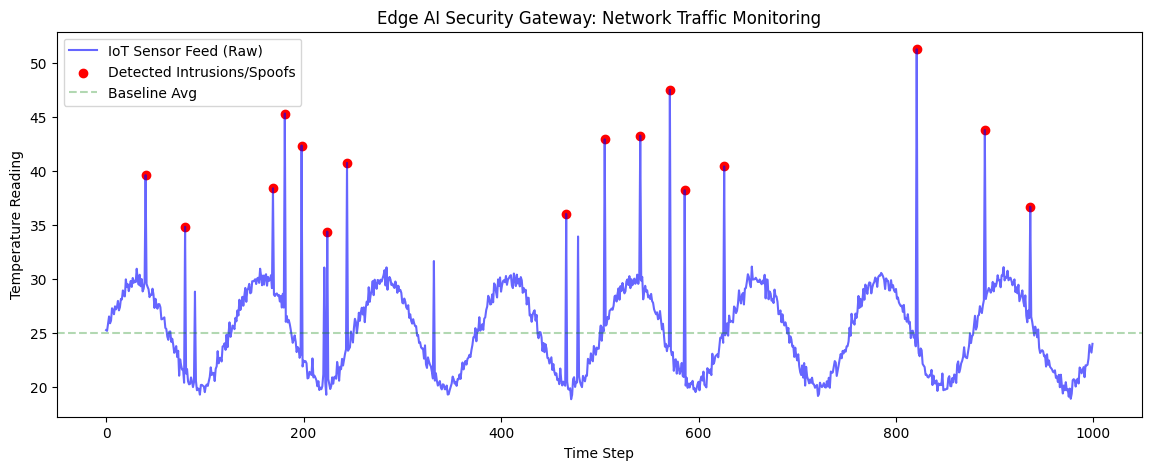


--- Edge Gateway Processing Log ---
[ALERT] Step 541: Anomalous reading (43.25) detected! Dropping packet. Smart contract event triggered.
[ALERT] Step 466: Anomalous reading (36.00) detected! Dropping packet. Smart contract event triggered.
[ALERT] Step 181: Anomalous reading (45.29) detected! Dropping packet. Smart contract event triggered.
[OK] Step 332: Reading (31.64) verified. Hash 44f58fb7a9... logged to blockchain.
[ALERT] Step 40: Anomalous reading (39.60) detected! Dropping packet. Smart contract event triggered.


In [ ]:
# Predict/Reconstruct the full dataset (including anomalies)
reconstructions = model.predict(X_test_scaled)
train_loss = tf.keras.losses.mae(reconstructions, X_test_scaled)

# Set a threshold for anomaly detection (e.g., 2 standard deviations above the mean loss)
threshold = np.mean(train_loss) + 2 * np.std(train_loss)
print(f"Anomaly Detection Threshold: {threshold:.4f}")

# Detect anomalies
anomalies = train_loss > threshold

# Plot the results
plt.figure(figsize=(14, 5))
plt.plot(iot_data['temperature'], label='IoT Sensor Feed (Raw)', color='blue', alpha=0.6)

# Highlight detected anomalies
anomaly_indices = np.where(anomalies)[0]
plt.scatter(anomaly_indices, iot_data['temperature'].iloc[anomaly_indices], color='red', label='Detected Intrusions/Spoofs')

plt.axhline(y=25, color='green', linestyle='--', alpha=0.3, label='Baseline Avg')
plt.title("Edge AI Security Gateway: Network Traffic Monitoring")
plt.xlabel("Time Step")
plt.ylabel("Temperature Reading")
plt.legend()
plt.show()

# Simulate the Smart Contract Gateway Decision
print("\n--- Edge Gateway Processing Log ---")
for i in range(5): # Check the first 5 instances of an attack
    idx = attack_indices[i]
    val = iot_data['temperature'].iloc[idx]
    is_anomaly = anomalies[idx]

    if is_anomaly:
        print(f"[ALERT] Step {idx}: Anomalous reading ({val:.2f}) detected! Dropping packet. Smart contract event triggered.")
    else:
        _, p_hash = generate_iot_payload_hash(val)
        print(f"[OK] Step {idx}: Reading ({val:.2f}) verified. Hash {p_hash[:10]}... logged to blockchain.")

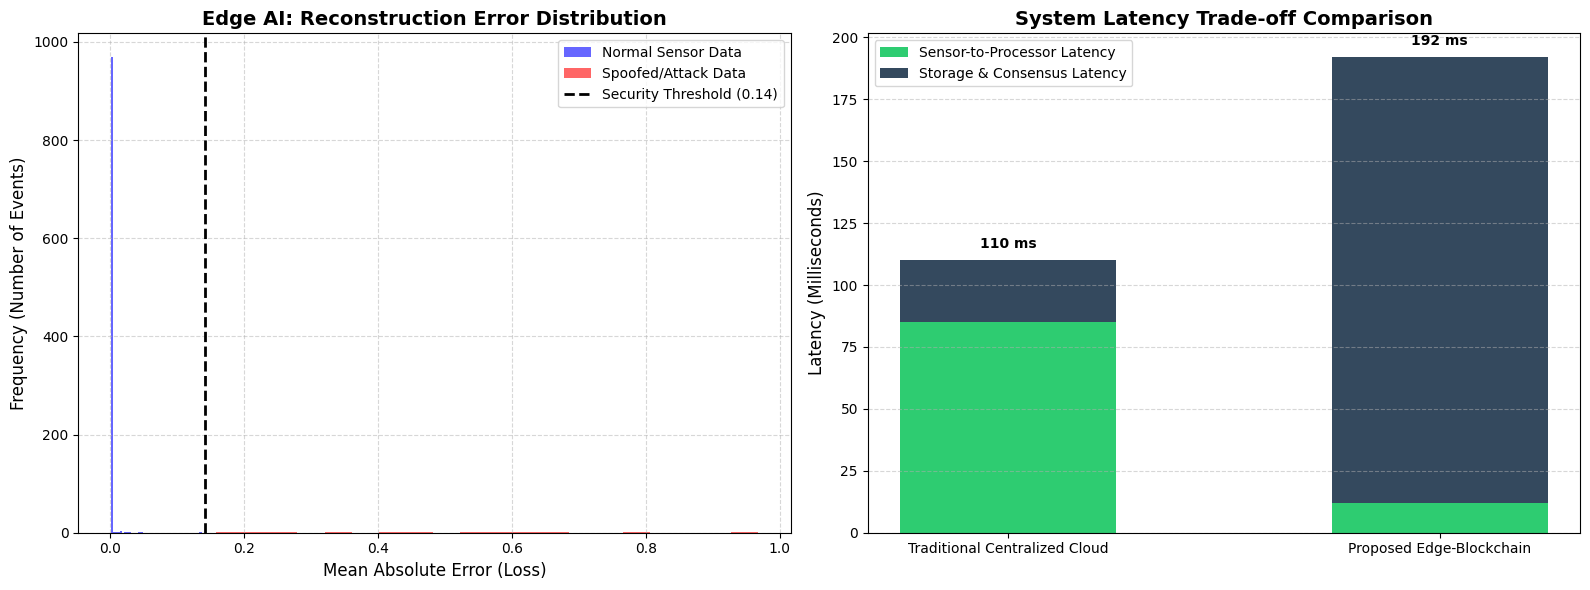

In [ ]:
# --- Cell 5: Performance & Security Analysis Dashboard ---

# Ensure variables from previous cells (train_loss, anomalies, threshold) are used
normal_errors = np.array(train_loss)[~anomalies]
attack_errors = np.array(train_loss)[anomalies]

# Create a 1x2 grid for our subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Graph 1: AI Reconstruction Error Distribution ---
ax1.hist(normal_errors, bins=40, color='blue', alpha=0.6, label='Normal Sensor Data')
ax1.hist(attack_errors, bins=20, color='red', alpha=0.6, label='Spoofed/Attack Data')
ax1.axvline(threshold, color='black', linestyle='dashed', linewidth=2, label=f'Security Threshold ({threshold:.2f})')

ax1.set_title('Edge AI: Reconstruction Error Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Mean Absolute Error (Loss)', fontsize=12)
ax1.set_ylabel('Frequency (Number of Events)', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Graph 2: System Architecture Latency Comparison ---
# Data reflecting Section 17 of the case study
architectures = ['Traditional Centralized Cloud', 'Proposed Edge-Blockchain']
sensor_to_processor = [85, 12]  # Milliseconds (Cloud takes longer; Edge is local)
consensus_storage = [25, 180]   # Milliseconds (Standard DB is fast; Blockchain takes time)

# Create Stacked Bar Chart
bar_width = 0.5
p1 = ax2.bar(architectures, sensor_to_processor, bar_width, color='#2ecc71', label='Sensor-to-Processor Latency')
p2 = ax2.bar(architectures, consensus_storage, bar_width, bottom=sensor_to_processor, color='#34495e', label='Storage & Consensus Latency')

ax2.set_title('System Latency Trade-off Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Latency (Milliseconds)', fontsize=12)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of the bars
for i in range(len(architectures)):
    total_latency = sensor_to_processor[i] + consensus_storage[i]
    ax2.text(i, total_latency + 5, f"{total_latency} ms", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()